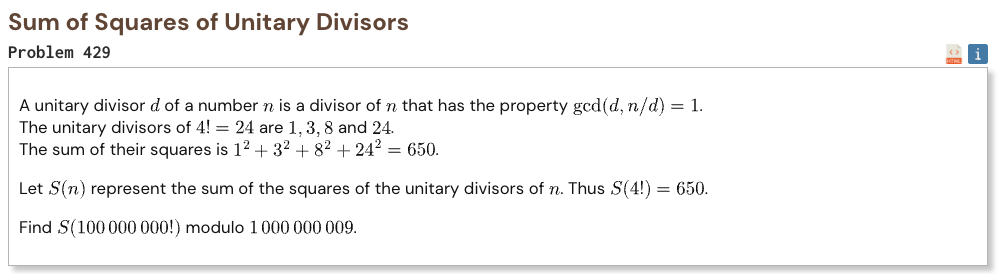

## Initial approach

-   find all primes up to one hundred million with a sieve
-   for each prime, find how many times it appears in the factorial
-   a unitary divisor either uses the full power of a prime or does not use that prime at all
-   this means each prime contributes two choices to the sum of squared divisors
-   calculate the squared full prime power for every prime
-   multiply all prime contributions together
-   take the modulo after every multiplication to keep numbers small

In [1]:
%%time

N = 100_000_000
MOD = 1_000_000_009

sieve = bytearray(b"\x01") * (N + 1)
sieve[0:2] = b"\x00\x00"

limit = int(N ** 0.5)

for p in range(2, limit + 1):
    if sieve[p]:
        start = p * p
        sieve[start:N + 1:p] = b"\x00" * (((N - start) // p) + 1)

result = 1

for p in range(2, N + 1):
    if sieve[p]:
        exponent = 0
        power = p

        while power <= N:
            exponent += N // power

            if power > N // p:
                break

            power *= p

        prime_power_squared = pow(p, 2 * exponent, MOD)
        result = result * (1 + prime_power_squared) % MOD

print("Result:", result)

Result: 98792821
CPU times: user 5.14 s, sys: 69.5 ms, total: 5.21 s
Wall time: 5.24 s
